In [ ]:
# =========================
# 1. Google Drive 연결
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# 2. 라이브러리
# =========================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# =========================
# 3. 사용자 설정
# =========================

csv_path = "/content/drive/MyDrive/Trainingdata.csv"

# 학습 target: "E", "n", "K", "YS" 중 하나 선택
target_column = "YS"

# feature 범위: F열부터 Q열까지
# 현재 CSV 기준으로는 Pmax ~ Slope5
feature_columns = [
    "Pmax", "Stiffness2","Slope1", "Slope2", "Slope3", "Slope4", "Slope5", "30um", "60um","90um","120um","150um"
]

# 데이터 분할 비율
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# 모델 저장 이름
model_name = "best_MLP_model_YS.keras"
save_dir = "/content/drive/MyDrive/trained_models"
os.makedirs(save_dir, exist_ok=True)
model_save_path = os.path.join(save_dir, model_name)

# 학습 설정
epochs = 4000
early_stopping_patience = 1000
batch_size = 32

learning_rate = 1e-3
l2_lambda = 1e-4
dropout_rate = 0.2

# 매번 random split
random_state = None


In [ ]:
# =========================
# 4. 데이터 불러오기
# =========================
df = pd.read_csv(csv_path)

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())

X = df[feature_columns].values.astype("float32")
y = df[target_column].values.reshape(-1, 1).astype("float32")


Data shape: (4500, 17)
Columns: ['number', 'E', 'n', 'K', 'YS', 'Pmax', 'Stiffness2', 'Slope1', 'Slope2', 'Slope3', 'Slope4', 'Slope5', '30um', '60um', '90um', '120um', '150um']


In [ ]:
# =========================
# 5. Train / Validation / Test 분할
# =========================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=train_ratio,
    random_state=random_state,
    shuffle=True
)

val_size_adjusted = val_ratio / (val_ratio + test_ratio)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    train_size=val_size_adjusted,
    random_state=random_state,
    shuffle=True
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3150, 12)
Validation: (675, 12)
Test: (675, 12)


In [ ]:
# =========================
# 6. Feature Min-Max Scaling
# =========================

scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

In [ ]:
# =========================
# 7. MAPE loss
# =========================

def mape_loss(y_true, y_pred):
    epsilon = tf.keras.backend.epsilon()
    return tf.reduce_mean(
        tf.abs((y_true - y_pred) / tf.maximum(tf.abs(y_true), epsilon))
    ) * 100.0

In [ ]:
# =========================
# 8. MLP 모델 구성
# 4 Dense layers + 1 Dropout layer
# =========================

model = Sequential([
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],),
        kernel_regularizer=l2(l2_lambda)
    ),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(l2_lambda)
    ),
    Dropout(dropout_rate),
    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(l2_lambda)
    ),
    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(l2_lambda)
    ),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss=mape_loss,
    metrics=[mape_loss]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,545 (111.50 KB)

 Trainable params: 28,545 (111.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# 9. Callback 설정
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=early_stopping_patience,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)


In [ ]:
# =========================
# 10. 학습
# =========================

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
90/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.0127 - mape_loss: 14.8041
Epoch 2758: val_loss did not improve from 16.15987
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.8077 - mape_loss: 14.5939 - val_loss: 16.7116 - val_mape_loss: 16.4583
Epoch 2759/4000
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.5388 - mape_loss: 14.3305
Epoch 2759: val_loss did not improve from 16.15987
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 15.0679 - mape_loss: 14.8614 - val_loss: 17.1011 - val_mape_loss: 16.9583
Epoch 2760/4000
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.8488 - mape_loss: 14.6405
Epoch 2760: val_loss did not improve from 16.15987
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 14.5587 - mape_loss: 14.3592 - val_loss: 19.2449 - val_mape_loss: 18.8883
Epoch 2761/4000
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.2157 - mape_loss: 15.0071
Epoch 2761: val_loss did not improve from 16.15987
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss

In [ ]:
# =========================
# 11. 최고 모델 불러오기 및 Test 성능 평가
# =========================

best_model = tf.keras.models.load_model(
    model_save_path,
    custom_objects={"mape_loss": mape_loss}
)

test_loss, test_mape = best_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

best_val_mape = min(history.history["val_loss"])

print(f"\nBest validation MAPE: {best_val_mape:.4f}%")
print(f"Test MAPE: {test_mape:.4f}%")
print(f"Best model saved at: {model_save_path}")


Best validation MAPE: 14.6256%
Test MAPE: 14.6951%
Best model saved at: /content/drive/MyDrive/trained_models/best_MLP_model_YS.keras


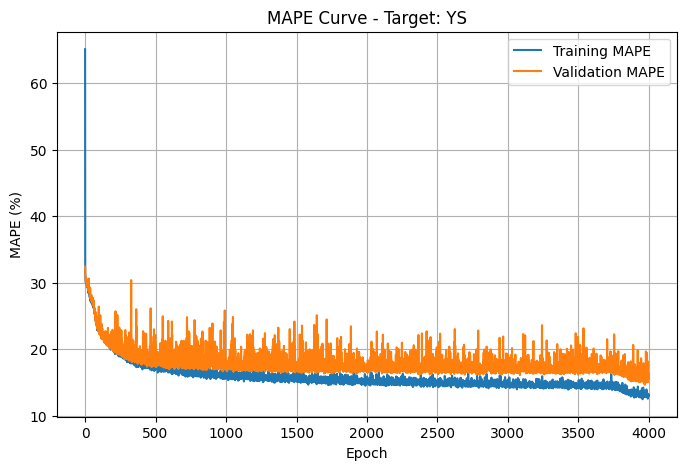

In [ ]:
# =========================
# 12. Epoch에 따른 MAPE 변화 그래프
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training MAPE")
plt.plot(history.history["val_loss"], label="Validation MAPE")
plt.xlabel("Epoch")
plt.ylabel("MAPE (%)")
plt.title(f"MAPE Curve - Target: {target_column}")
plt.legend()
plt.grid(True)
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Test MAPE from prediction: 14.6925%


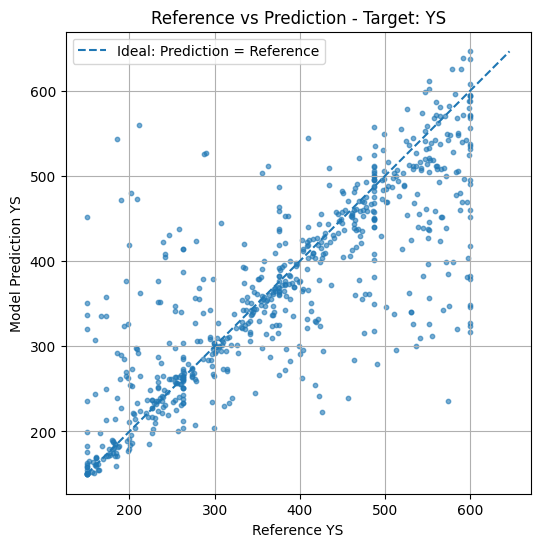

In [ ]:
# =========================
# 13. Test data: Reference vs Model Prediction Plot
# =========================

# 사용자가 조절할 수 있는 plotting 옵션
point_size = 10       # 점 크기
point_alpha = 0.6     # 투명도, 0~1 사이

# 최고 성능 모델로 test 예측
y_test_pred = best_model.predict(X_test_scaled)

# 1D array로 변환
y_ref = y_test.flatten()
y_pred = y_test_pred.flatten()

# MAPE 계산
test_mape_manual = np.mean(np.abs((y_ref - y_pred) / y_ref)) * 100

print(f"Test MAPE from prediction: {test_mape_manual:.4f}%")

# Reference-Prediction plot
plt.figure(figsize=(6, 6))
plt.scatter(
    y_ref,
    y_pred,
    s=point_size,
    alpha=point_alpha
)

# y = x 기준선
min_val = min(y_ref.min(), y_pred.min())
max_val = max(y_ref.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Ideal: Prediction = Reference"
)

plt.xlabel(f"Reference {target_column}")
plt.ylabel(f"Model Prediction {target_column}")
plt.title(f"Reference vs Prediction - Target: {target_column}")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()